Shape of X: (208, 20)

Feature columns:
max_metal_ligand_bond_length
SGR No.
mean_metal_ligand_bond_length
vol_per_atom
avg_Martynov-Batsanov EN
polyhedron volume
avg_Thermal conductivity (W/m•K)
avg_Number of outer shell electrons
std_Heat of fusion (kJ/mol)
1/R2
avg_Number of d electrons
std_Number of outer shell electrons
avg_Mulliken EN
avg_First ionization energy (kJ/mol)
c
std_Number of valence electrons
max_Heat atomization (kJ/mol)
std_Atomic weight
distortion_index
std_Thermal conductivity (W/m•K)


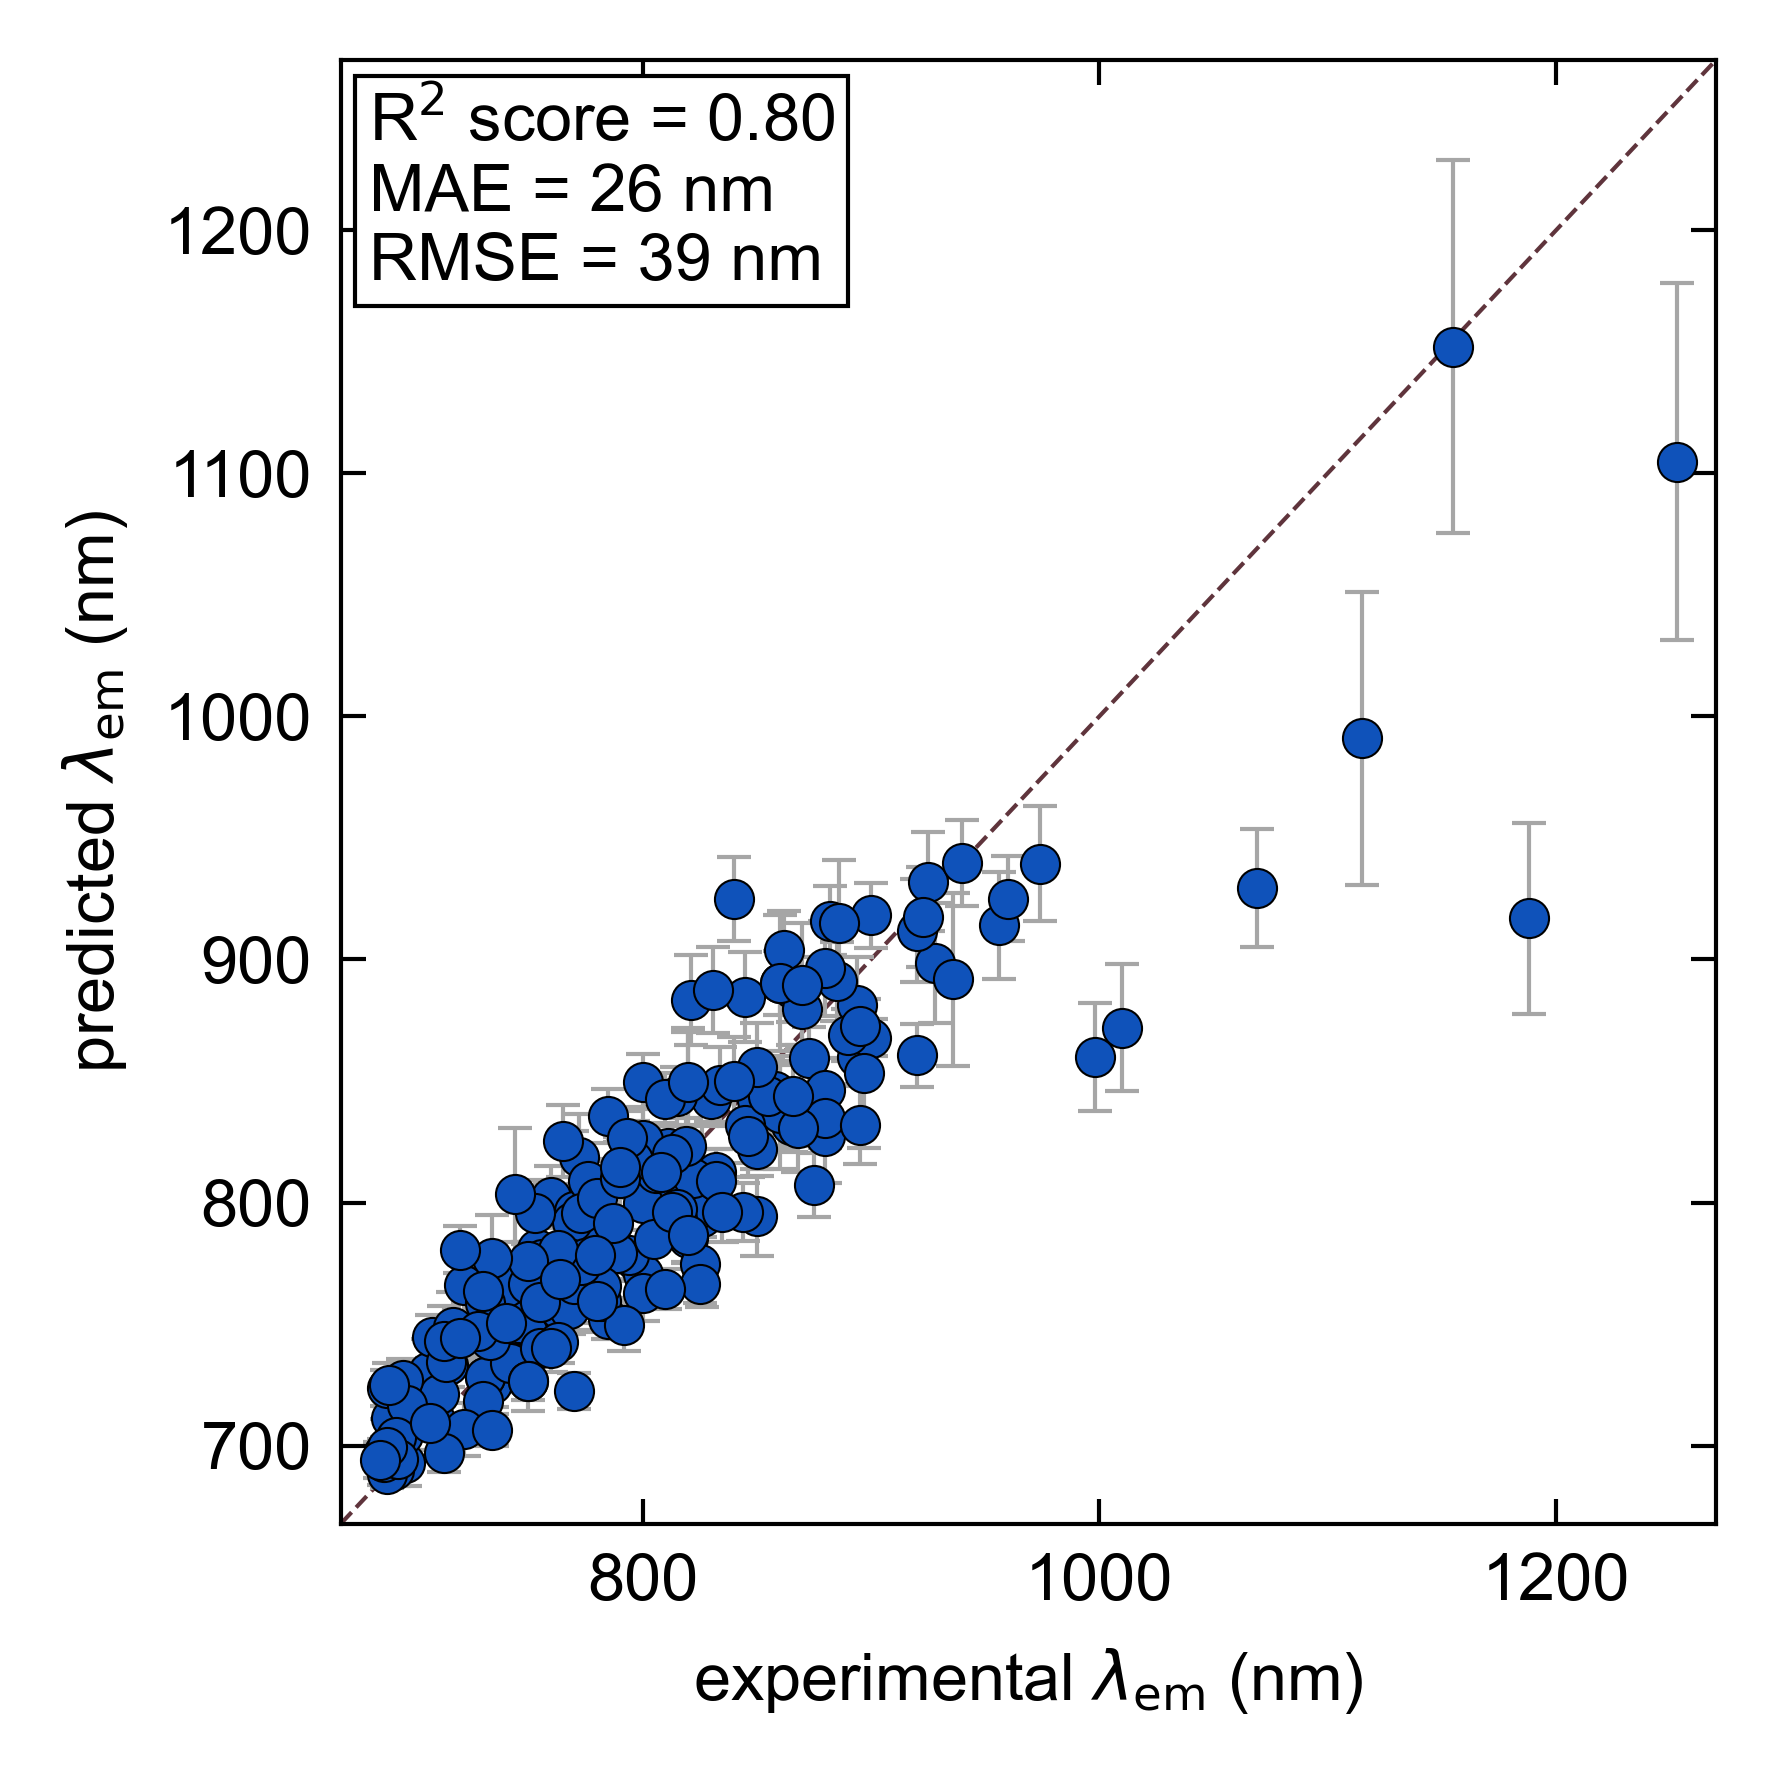

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


EV_NM = 1239.8419843320026

PLOT_RS = 5
N_SPLITS = 10
UNCERTAINTY_RS = [5, 55, 5]
N_BOOT = 10

ORANGE = "#5F343C"
BLUE = "#0F52BA"

params = {
    "iterations": 2092,
    "learning_rate": 0.024495702352497536,
    "depth": 4,
    "l2_leaf_reg": 2,
    "random_strength": 2.5013784369774434,
    "subsample": 0.8923775826709153,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "verbose": False,
}


def make_model(seed=42):
    p = params.copy()
    p["random_seed"] = seed
    return CatBoostRegressor(**p)


def nm_pred(model, scaler, X_data):
    pred_ev = model.predict(scaler.transform(X_data))
    if np.any(pred_ev <= 0):
        raise ValueError("Non-positive predicted energy found.")
    return EV_NM / pred_ev


df = pd.read_excel("trainingset_em.xlsx")
df.columns = df.columns.astype(str).str.strip()

y_nm = pd.to_numeric(df.iloc[:, 1], errors="coerce")
X = df.iloc[:, 3:].apply(pd.to_numeric, errors="coerce")
feature_cols = X.columns.tolist()

if y_nm.isna().any() or (y_nm <= 0).any():
    raise ValueError("Invalid target values.")

if X.isna().any().any():
    bad_cols = X.columns[X.isna().any()].tolist()
    raise ValueError(f"Invalid feature columns: {bad_cols}")

y_ev = EV_NM / y_nm
actual_nm = y_nm.to_numpy()

print("Shape of X:", X.shape)
print("\nFeature columns:")
for col in feature_cols:
    print(col)


pred_nm = np.zeros(len(X))

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=PLOT_RS,
)

for train_idx, val_idx in kf.split(X):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X.iloc[train_idx])
    X_val_scaled = scaler.transform(X.iloc[val_idx])

    model = make_model(42)

    model.fit(
        X_train_scaled,
        y_ev.iloc[train_idx],
        eval_set=(X_val_scaled, y_ev.iloc[val_idx]),
        use_best_model=True,
        early_stopping_rounds=100,
    )

    pred_nm[val_idx] = nm_pred(
        model,
        scaler,
        X.iloc[val_idx],
    )


r2 = r2_score(actual_nm, pred_nm)
mae = mean_absolute_error(actual_nm, pred_nm)
rmse = mean_squared_error(actual_nm, pred_nm) ** 0.5


unc_preds = [[] for _ in range(len(X))]

for rs in UNCERTAINTY_RS:
    kf = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=rs,
    )

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_pool = X.iloc[train_idx]
        y_pool = y_ev.iloc[train_idx]

        rng = np.random.default_rng(rs * 1000 + fold)

        for boot_num in range(N_BOOT):
            boot_idx = rng.choice(
                len(train_idx),
                size=len(train_idx),
                replace=True,
            )

            scaler = StandardScaler()
            X_boot_scaled = scaler.fit_transform(X_pool.iloc[boot_idx])

            model = make_model(
                rs * 10000 + fold * 100 + boot_num
            )

            model.fit(
                X_boot_scaled,
                y_pool.iloc[boot_idx],
            )

            fold_pred_nm = nm_pred(
                model,
                scaler,
                X.iloc[val_idx],
            )

            for i, p in zip(val_idx, fold_pred_nm):
                unc_preds[i].append(p)


expected = len(UNCERTAINTY_RS) * N_BOOT
counts = np.array([len(p) for p in unc_preds])

if not np.all(counts == expected):
    raise ValueError(
        f"Expected {expected} predictions per point, got {np.unique(counts)}"
    )

unc_nm = np.array([
    np.std(p, ddof=1)
    for p in unc_preds
])


fonts = {f.name for f in fm.fontManager.ttflist}
font = (
    "Helvetica" if "Helvetica" in fonts
    else "Arial" if "Arial" in fonts
    else "DejaVu Sans"
)

plt.rcParams.update({
    "font.family": font,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "mathtext.fontset": "dejavusans",
})


fig, ax = plt.subplots(figsize=(3, 3), dpi=600)

ax.errorbar(
    actual_nm,
    pred_nm,
    yerr=unc_nm,
    fmt="none",
    ecolor="0.65",
    elinewidth=0.5,
    capsize=2,
    capthick=0.5,
    zorder=1,
)

ax.scatter(
    actual_nm,
    pred_nm,
    s=22,
    color=BLUE,
    edgecolor="black",
    linewidth=0.25,
    zorder=2,
)

lo = min(actual_nm.min(), pred_nm.min())
hi = max(actual_nm.max(), pred_nm.max())
pad = 0.03 * (hi - lo)

lo -= pad
hi += pad

ax.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color=ORANGE,
    linewidth=0.5,
    zorder=0,
)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

ax.set_xlabel(r"experimental $\lambda_{\mathrm{em}}$ (nm)")
ax.set_ylabel(r"predicted $\lambda_{\mathrm{em}}$ (nm)")

ax.text(
    0.02,
    0.98,
    f"R$^2$ score = {r2:.2f}\nMAE = {mae:.0f} nm\nRMSE = {rmse:.0f} nm",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        linewidth=0.5,
        boxstyle="square,pad=0.2",
    ),
    zorder=5,
)

ax.tick_params(
    axis="both",
    which="both",
    direction="in",
    length=3,
    width=0.5,
    top=True,
    right=True,
)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)

fig.tight_layout()
plt.show()

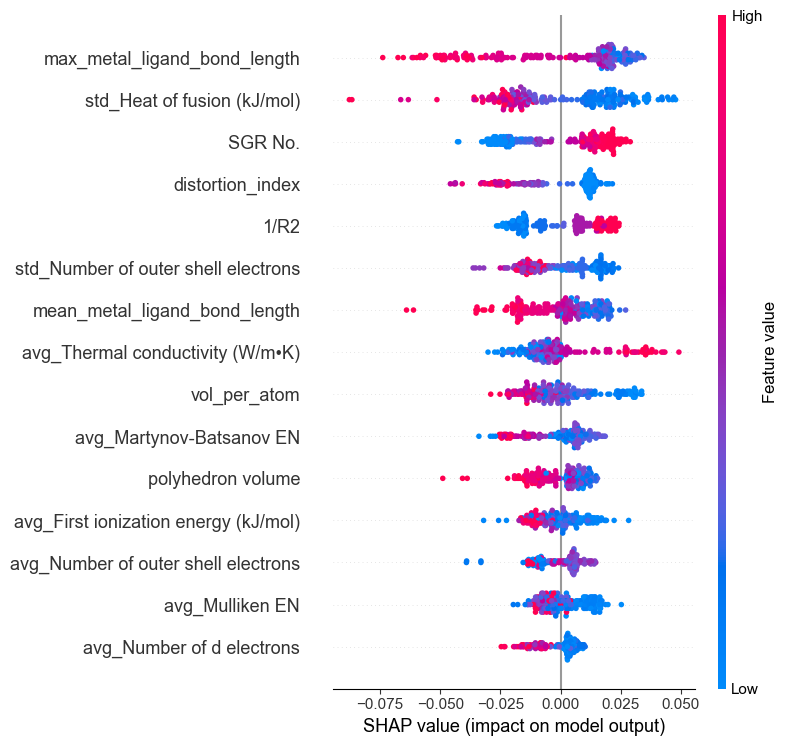

In [8]:
import shap

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = make_model(42)
model.fit(X_scaled, y_ev)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

shap.summary_plot(
    shap_values,
    X,
    max_display=15,
    show=True,
)

In [9]:
predict_df = pd.read_excel("To_predict_em.xlsx")
predict_df.columns = predict_df.columns.astype(str).str.strip()

X_new = predict_df.iloc[:, 2:].apply(pd.to_numeric, errors="coerce")

if X_new.shape[1] != X.shape[1]:
    raise ValueError("Prediction feature count does not match training data.")

X_new.columns = X.columns

if X_new.isna().any().any():
    bad_cols = X_new.columns[X_new.isna().any()].tolist()
    raise ValueError(f"Invalid prediction columns: {bad_cols}")

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

model = make_model(42)
model.fit(X_scaled, y_ev)

pred_new_nm = nm_pred(model, sc, X_new)

new_unc_preds = []

for rs in UNCERTAINTY_RS:
    kf = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=rs,
    )

    for fold, (train_idx, _) in enumerate(kf.split(X)):
        X_pool = X.iloc[train_idx]
        y_pool = y_ev.iloc[train_idx]

        rng = np.random.default_rng(rs * 1000 + fold)

        for boot_num in range(N_BOOT):
            boot_idx = rng.choice(
                len(train_idx),
                size=len(train_idx),
                replace=True,
            )

            sc_b = StandardScaler()
            X_boot_scaled = sc_b.fit_transform(
                X_pool.iloc[boot_idx]
            )

            model_b = make_model(
                rs * 10000 + fold * 100 + boot_num
            )

            model_b.fit(
                X_boot_scaled,
                y_pool.iloc[boot_idx],
            )

            new_unc_preds.append(
                nm_pred(
                    model_b,
                    sc_b,
                    X_new,
                )
            )

new_unc_nm = np.std(
    np.array(new_unc_preds),
    axis=0,
    ddof=1,
)

out = pd.DataFrame({
    "Formula": predict_df.iloc[:, 0],
    "Predicted_Emission_nm": pred_new_nm,
    "Uncertainty_nm": new_unc_nm,
})

if "1/R2" in predict_df.columns:
    out["R"] = np.sqrt(
        1 / pd.to_numeric(
            predict_df["1/R2"],
            errors="coerce",
        )
    )

if "SGR No." in predict_df.columns:
    out["SGR No."] = predict_df["SGR No."]

out.to_excel(
    "predicted_em.xlsx",
    index=False,
)

print("predicted_em has been saved")

predicted_em has been saved
